In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train_df = pd.read_csv("data/aps_failure_training_set.csv", skiprows=20)
train_df = train_df.replace("na", np.nan)
shape = train_df.shape
print(f"Number of samples: {shape[0]}")
# COUNT The number of samples in each class
print(f"Number of samples in each class:\n{train_df['class'].value_counts()}")
# Answer:
# neg    59000  (healthy)
# pos     1000  (broken)

Number of samples: 60000
Number of samples in each class:
class
neg    59000
pos     1000
Name: count, dtype: int64


<Axes: title={'center': 'Number of missing values for each feature'}>

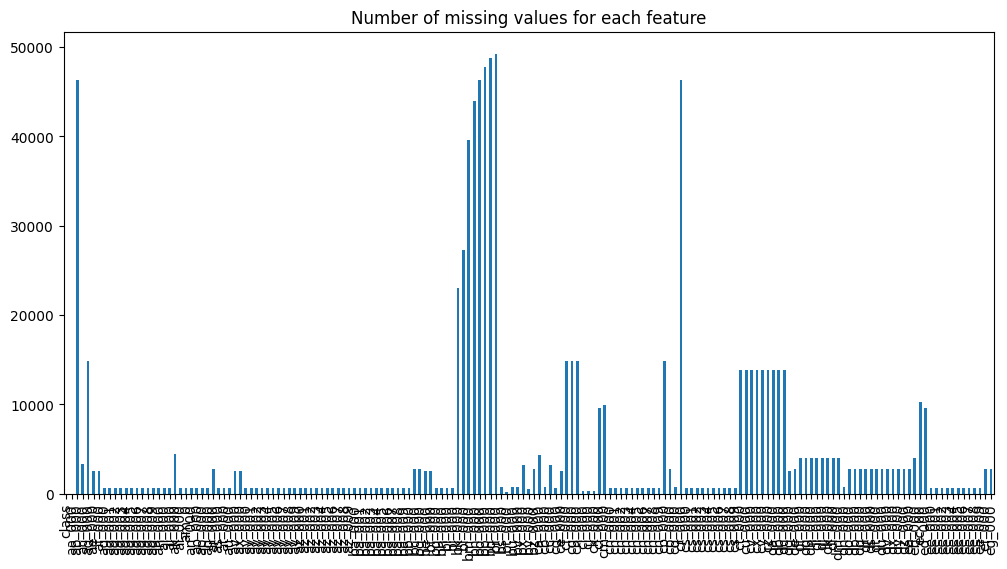

In [4]:
missing_values_count = train_df.isna().sum()
train_df.isna().sum().plot(
    kind="bar", figsize=(12, 6), title="Number of missing values for each feature"
)

In [5]:
# Get the top 10 features with the most missing values
missing_values_count.sort_values(ascending=False).head(10)


# Calculate the percentage of missing values for each feature
missing_values_perc = missing_values_count / len(train_df) * 100

print(
    f"The percentage of missing values for each feature (TOP 10):\n{missing_values_perc.sort_values(ascending=False).head(10)}"
)

The percentage of missing values for each feature (TOP 10):
br_000    82.106667
bq_000    81.203333
bp_000    79.566667
bo_000    77.221667
ab_000    77.215000
cr_000    77.215000
bn_000    73.348333
bm_000    65.915000
bl_000    45.461667
bk_000    38.390000
dtype: float64


In [6]:
# Separate positive class and negative class
positive_class = train_df[train_df["class"] == "pos"]
negative_class = train_df[train_df["class"] == "neg"]

print(f"Number of samples in positive class: {len(positive_class)}")
print(f"Number of samples in negative class: {len(negative_class)}")

Number of samples in positive class: 1000
Number of samples in negative class: 59000


In [7]:
# For each feature, calculate the difference between healthy and failing

feature_comparison = []

for feature in train_df.columns:
    if feature == "class":  # Skip the target column
        continue

    # Get values, handling missing data
    healthy_values = positive_class[feature].dropna()
    failing_values = negative_class[feature].dropna()

    # Calculate statistics
    healthy_values = pd.to_numeric(healthy_values, errors="coerce").dropna()
    failing_values = pd.to_numeric(failing_values, errors="coerce").dropna()

    healthy_mean = healthy_values.mean()
    healthy_std = healthy_values.std()

    failing_mean = failing_values.mean()
    failing_std = failing_values.std()

    # Calculate the DIFFERENCE (in standard deviations)
    # This is called "effect size" or "Cohen's d"
    if healthy_std > 0:
        difference = (failing_mean - healthy_mean) / healthy_std
    else:
        difference = 0

    feature_comparison.append(
        {
            "feature": feature,
            "healthy_mean": healthy_mean,
            "healthy_std": healthy_std,
            "failing_mean": failing_mean,
            "failing_std": failing_std,
            "difference": abs(difference),  # Use absolute value
            "percent_healthy_missing": (1 - len(healthy_values) / len(positive_class))
            * 100,
            "percent_failing_missing": (1 - len(failing_values) / len(negative_class))
            * 100,
        }
    )

# Convert to dataframe and sort by difference
comparison_df = pd.DataFrame(feature_comparison)
comparison_df = comparison_df.sort_values("difference", ascending=False)

print("\nTop 20 Features Most Different Between Healthy and Failing:")
print(comparison_df[["feature", "healthy_mean", "failing_mean", "difference"]].head(20))


Top 20 Features Most Different Between Healthy and Failing:
    feature  healthy_mean  failing_mean  difference
3    ad_000  2.262214e+03  1.921137e+05   34.749606
91   cf_000  1.429527e+03  1.917184e+05   30.161132
109  co_000  4.080265e+03  1.919934e+05    7.448033
122  cs_009  1.077108e+01  7.923177e+02    4.120934
138  dj_000  6.932773e-01  4.027505e+01    3.037265
94   ci_000  3.907378e+07  2.880634e+06    1.536845
16   ah_000  1.894443e+07  1.528542e+06    1.523169
67   bg_000  1.888342e+07  1.529644e+06    1.518931
62   bb_000  5.063363e+07  3.768984e+06    1.498558
82   bv_000  5.041831e+07  3.761695e+06    1.495702
81   bu_000  5.041830e+07  3.761695e+06    1.495702
111  cq_000  5.041830e+07  3.761695e+06    1.495702
22   an_000  3.537163e+07  2.938128e+06    1.473698
78   br_000  3.477114e+05  6.287040e+05    1.442035
140  dl_000  8.897269e+02  2.877887e+04    1.436729
23   ao_000  3.066685e+07  2.548080e+06    1.432023
80   bt_000  6.623817e+05  4.928238e+04    1.411778
0  

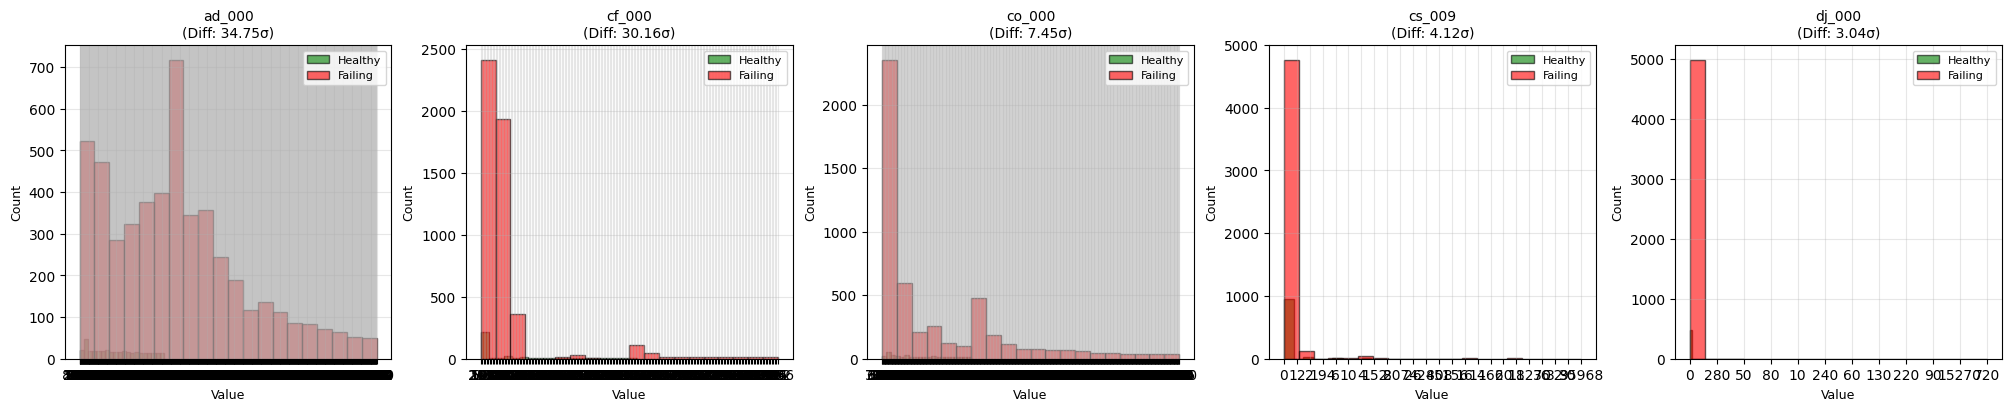

✅ Top 5 features plot saved!

Top 20 Features Ranked by Difference (Healthy vs Failing)
feature Healthy Mean Failing Mean  Difference (σ)  % Missing (Healthy)  % Missing (Failing)
 ad_000     2.26e+03     1.92e+05          34.750                 64.5                24.09
 cf_000     1.43e+03     1.92e+05          30.161                 64.5                24.09
 co_000     4.08e+03     1.92e+05           7.448                 64.5                24.09
 cs_009     1.08e+01     7.92e+02           4.121                  0.4                 1.13
 dj_000     6.93e-01     4.03e+01           3.037                 52.4                 5.90
 ci_000     3.91e+07     2.88e+06           1.537                  1.0                 0.56
 ah_000     1.89e+07     1.53e+06           1.523                  4.1                 1.02
 bg_000     1.89e+07     1.53e+06           1.519                  4.3                 1.02
 bb_000     5.06e+07     3.77e+06           1.499                  4.1              

In [ ]:
# Plot the top 5 most different features

top_n_plot = 5
top_features_plot = comparison_df.head(top_n_plot)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), constrained_layout=True)
if top_n_plot == 1:
    axes = [axes]

max_points = 5000

for idx, (_, row) in enumerate(top_features_plot.iterrows()):
    feature = row["feature"]

    healthy_data = positive_class[feature].dropna()
    failing_data = negative_class[feature].dropna()

    if len(healthy_data) > max_points:
        healthy_data = healthy_data.sample(max_points, random_state=42)
    if len(failing_data) > max_points:
        failing_data = failing_data.sample(max_points, random_state=42)

    ax = axes[idx]
    ax.hist(
        healthy_data,
        bins=20,
        alpha=0.6,
        label="Healthy",
        color="green",
        edgecolor="black",
    )
    ax.hist(
        failing_data,
        bins=20,
        alpha=0.6,
        label="Failing",
        color="red",
        edgecolor="black",
    )

    ax.set_title(f"{feature}\n(Diff: {row['difference']:.2f}σ)", fontsize=10)
    ax.set_xlabel("Value", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.savefig("top_5_features_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(">>> Top 5 features plot saved!")

# Display remaining top features in a table
print("\n" + "=" * 80)
print("Top 20 Features Ranked by Difference (Healthy vs Failing)")
print("=" * 80)

display_cols = [
    "feature",
    "healthy_mean",
    "failing_mean",
    "difference",
    "percent_healthy_missing",
    "percent_failing_missing",
]
display_df = comparison_df[display_cols].head(20).copy()
display_df = display_df.rename(
    columns={
        "healthy_mean": "Healthy Mean",
        "failing_mean": "Failing Mean",
        "difference": "Difference (σ)",
        "percent_healthy_missing": "% Missing (Healthy)",
        "percent_failing_missing": "% Missing (Failing)",
    }
)
display_df["Difference (σ)"] = display_df["Difference (σ)"].round(3)
display_df["Healthy Mean"] = display_df["Healthy Mean"].apply(lambda x: f"{x:.2e}")
display_df["Failing Mean"] = display_df["Failing Mean"].apply(lambda x: f"{x:.2e}")
display_df["% Missing (Healthy)"] = display_df["% Missing (Healthy)"].round(2)
display_df["% Missing (Failing)"] = display_df["% Missing (Failing)"].round(2)

print(display_df.to_string(index=False))
print("\nTable saved!")

In [10]:
# Show the top features clearly

top_features = comparison_df.head(20).copy()

print("\n" + "=" * 100)
print("TOP 20 FEATURES MOST DIFFERENT IN FAILING TRUCKS")
print("=" * 100)
print(
    f"\n{'Feature':<15} {'Healthy Mean':<15} {'Failing Mean':<15} {'Difference (σ)':<15}"
)
print("-" * 100)

for _, row in top_features.iterrows():
    print(
        f"{row['feature']:<15} {row['healthy_mean']:>14.2f} {row['failing_mean']:>14.2f} {row['difference']:>14.2f}"
    )

print("\n" + "=" * 100)
print("INTERPRETATION:")
print("=" * 100)
print(
    """
Difference (σ) = How many standard deviations apart are the two groups?

Examples:
  - 0.5σ = Slightly different
  - 1.0σ = Clearly different
  - 2.0σ = Very different
  - 5.0σ = Extremely different (DEFINITELY a signal!)

Features with high σ differences are your "probable causes"
"""
)


TOP 20 FEATURES MOST DIFFERENT IN FAILING TRUCKS

Feature         Healthy Mean    Failing Mean    Difference (σ) 
----------------------------------------------------------------------------------------------------
ad_000                 2262.21      192113.74          34.75
cf_000                 1429.53      191718.36          30.16
co_000                 4080.26      191993.43           7.45
cs_009                   10.77         792.32           4.12
dj_000                    0.69          40.28           3.04
ci_000             39073777.76     2880633.96           1.54
ah_000             18944426.42     1528542.37           1.52
bg_000             18883423.26     1529644.50           1.52
bb_000             50633627.05     3768984.15           1.50
bv_000             50418307.49     3761695.41           1.50
bu_000             50418302.00     3761694.91           1.50
cq_000             50418302.11     3761695.39           1.50
an_000             35371629.71     2938127.55       